In [2]:
import sys
from pathlib import Path
import time
import json

# For resolving ModuleNotFoundErrors
notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent.resolve()
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import subprocess
import numpy as np
import matplotlib.pyplot as plt
from asyncroscopy.ThermoMicroscope import ThermoMicroscope
from tango.test_context import MultiDeviceTestContext
from asyncroscopy.detectors.EDS import EDS
from asyncroscopy.hardware.SCAN import SCAN

import tango

True


## 1. Connect to devices

In [20]:
# ── Kill anything already on port 11000 ──────────────────────────────────────
print("Clearing old processes...")
subprocess.run("kill -9 $(lsof -t -i:11000) 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'STAGE stage' 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'SCAN scan' 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true", shell=True)
time.sleep(2)

Clearing old processes...


In [21]:
devices_info = [
    {
        "class": SCAN,
        "devices": [
            {
                "name": "test/detector/scan",
                "properties": {},
            }
        ],
    },

    {
        "class": EDS,
        "devices": [
            {
                "name": "test/detector/eds",
                "properties": {},
            }
        ],
    },
    
    {
        "class": ThermoMicroscope,
        "devices": [
            {
                "name": "test/detector/microscope",
                "properties": {
                    "eds_device_address": "test/detector/eds",
                    "scan_device_address": "test/detector/scan",
                },
            }
        ],
    },
]

ctx = MultiDeviceTestContext(devices_info, process=False)
ctx.start()

scan_proxy = tango.DeviceProxy("test/detector/scan")
mic_proxy = tango.DeviceProxy("test/detector/microscope")
eds_proxy = tango.DeviceProxy("test/detector/eds")

print(f"Device state: {mic_proxy.state()}")


Ready to accept request
Device state: ON


## 2. Inspect device attributes and commands

In [22]:
print('\n--- Microscope commands ---')
for cmd in mic_proxy.get_command_list():
    print(f'  {cmd}')


--- Microscope commands ---
  Connect
  Disconnect
  Init
  State
  Status
  blank_beam
  get_image_data_cached
  get_images
  get_scanned_image
  get_spectrum
  get_stage
  move_stage
  place_beam
  set_fov
  unblank_beam


In [23]:
print('\n--- Microscope commands ---')
for cmd in scan_proxy.get_command_list():
    print(f'  {cmd}')


--- Microscope commands ---
  Activate
  Init
  State
  Status


## 3. Configure HAADF detector settings

In [25]:
scan_proxy.dwell_time 

1e-06

In [27]:
scan_proxy.dwell_time   = 1e-6   # 1 µs
scan_proxy.imsize  = 1024

print('dwell_time  :', scan_proxy.dwell_time)
print('image_width :', scan_proxy.imsize)

dwell_time  : 1e-06
image_width : 1024


## 4. Acquire a HAADF image

In [29]:
# get_image returns DevEncoded = (json_metadata_str, raw_bytes)
json_meta, raw_bytes = mic_proxy.get_scanned_image()

metadata  = dict(json.loads(json_meta))
image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

print('Metadata:', metadata)
print('Image shape:', image.shape)
print('Image dtype:', image.dtype)

Metadata: {'detector': 'haadf', 'shape': [1024, 1024], 'dtype': 'uint16', 'dwell_time': 1e-06, 'timestamp': 1774450865.2172449}
Image shape: (1024, 1024)
Image dtype: uint16


## 5. Display the image

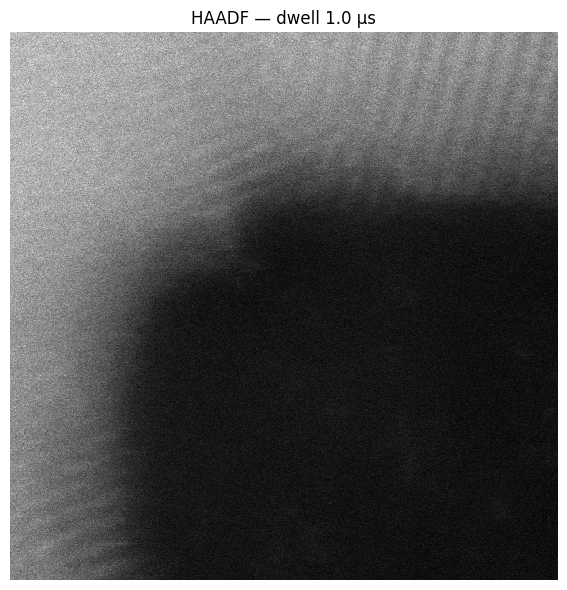

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap='gray', interpolation='none')
ax.set_title(f"HAADF — dwell {metadata['dwell_time']*1e6:.1f} µs")
ax.axis('off')
plt.tight_layout()
plt.show()

### Sidpy dataset

In [10]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

import sidpy
print('sidpy version: ', sidpy.__version__)

sidpy version:  0.12.8


In [11]:
dataset = sidpy.Dataset.from_array(image , name='HAADF')

# set dimesnions
dataset.set_dimension(0, sidpy.Dimension(np.arange(image.shape[0])*.02, 'x'))
dataset.set_dimension(1, sidpy.Dimension(np.arange(image.shape[0])*.02, 'y'))


# set the dataset level plotting metadata
dataset.data_type = 'image'
dataset.units = 'counts'
dataset.quantity = 'intensity'
dataset.title = 'HAADF'

# handle one dimension of the data
dataset.set_dimension(0, sidpy.Dimension(np.arange(dataset.shape[0])*.02, 'x'))
dataset.x.dimension_type = 'spatial'
dataset.x.units = 'nm'
dataset.x.quantity = 'distance'

# handle another dimension of the data

dataset.set_dimension(1, sidpy.Dimension(np.arange(dataset.shape[1])*.02, 'y'))
dataset.y.dimension_type = 'spatial'
dataset.y.units = 'nm'
dataset.y.quantity = 'distance'

In [12]:
dataset.metadata = metadata

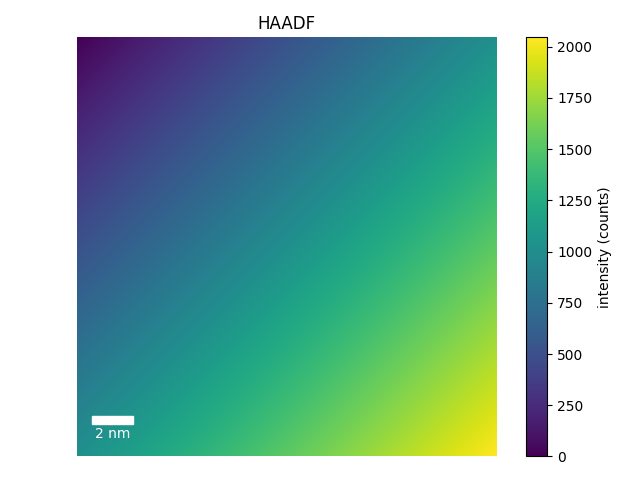

In [14]:
view = dataset.plot(scale_bar=True)

## 6. Advanced acquisition (multi-detector)

#### Start the Advanced acquisiiton

```bash
uv run python -m tango.test_context asyncroscopy.AdvancedAcquisition.AdvancedAcquisition \
  --host 127.0.0.1 \
  --port 8890
```


#### Start the Microscope
```bash
uv run python -m tango.test_context asyncroscopy.Microscope.Microscope --host 127.0.0.1 --port 8889 \
  --prop "{'haadf_device_address': 'tango://127.0.0.1:8888/test/nodb/haadf#dbase=no', 'advanced_acquisition_device_address': 'tango://127.0.0.1:8890/test/nodb/advancedacquisition#dbase=no', 'autoscript_host_ip': '10.46.217.242', 'autoscript_host_port': 9090}"


In [41]:
adv_acq_proxy = tango.DeviceProxy("tango://127.0.0.1:8890/test/nodb/advancedacquisition#dbase=no")


In [42]:
adv_acq_proxy.state()

<DevState.ON: 0>

In [43]:
for attr in adv_acq_proxy.get_attribute_list():
    print(f'  {attr}')



  dwell_time
  base_resolution
  scan_region
  auto_beam_blank
  State
  Status


In [44]:
adv_acq_proxy.dwell_time

1e-06

In [52]:
adv_acq_proxy.scan_region

array([0. , 0. , 0.2, 0.8])

In [ ]:
adv_acq_proxy.scan_region = [0, 0, 1, 1]

In [54]:
# One simultaneous acquisition
response = microscope_proxy.get_images(["HAADF"])
info = json.loads(response)


In [55]:
info

{'images': [{'index': 0,
   'detector': 'haadf',
   'shape': [1024, 1024],
   'dtype': 'uint16',
   'timestamp': 1771975855.342685}],
 'count': 1}

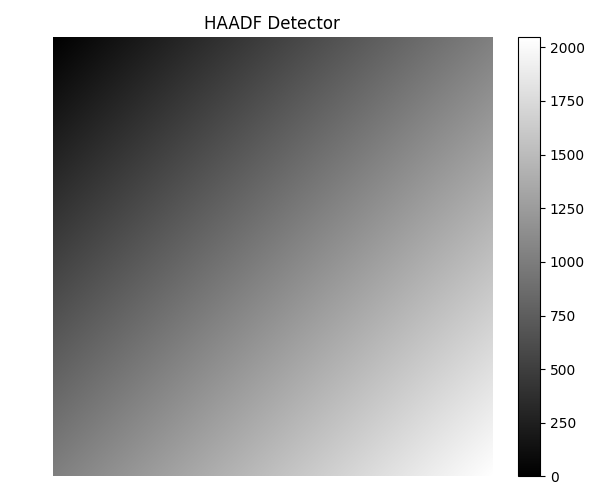

In [56]:
import matplotlib.pyplot as plt

# Quick retrieval
images = []
for img_meta in info["images"]:
    meta_json, img_bytes = microscope_proxy.get_image_data_cached(img_meta["index"])
    img = np.frombuffer(img_bytes, dtype=img_meta["dtype"]).reshape(img_meta["shape"])
    images.append((img_meta["detector"], img))

# Plot all images
fig, axes = plt.subplots(1, len(images), figsize=(6*len(images), 5))

# Handle single image case
if len(images) == 1:
    axes = [axes]

for ax, (detector_name, img) in zip(axes, images):
    im = ax.imshow(img, cmap='gray')
    ax.set_title(f"{detector_name.upper()} Detector")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### get image with rectangular scan region

In [59]:
adv_acq_proxy.scan_region = [0, 0, 0.2, 0.8]
# One simultaneous acquisition
response = microscope_proxy.get_images(["HAADF"])
info = json.loads(response)


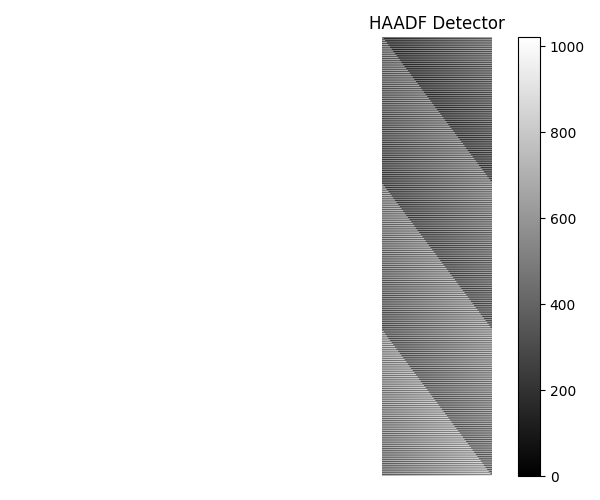

In [60]:
import matplotlib.pyplot as plt

# Quick retrieval
images = []
for img_meta in info["images"]:
    meta_json, img_bytes = microscope_proxy.get_image_data_cached(img_meta["index"])
    img = np.frombuffer(img_bytes, dtype=img_meta["dtype"]).reshape(img_meta["shape"])
    images.append((img_meta["detector"], img))

# Plot all images
fig, axes = plt.subplots(1, len(images), figsize=(6*len(images), 5))

# Handle single image case
if len(images) == 1:
    axes = [axes]

for ax, (detector_name, img) in zip(axes, images):
    im = ax.imshow(img, cmap='gray')
    ax.set_title(f"{detector_name.upper()} Detector")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Sidpy

In [61]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sidpy

# Step 1: Acquire images simultaneously
response = microscope_proxy.get_images(["HAADF"])
info = json.loads(response)

# Step 2: Create sidpy datasets for each image
datasets = []

for img_meta in info["images"]:
    # Get the cached image
    meta_json, img_bytes = microscope_proxy.get_image_data_cached(img_meta["index"])
    img = np.frombuffer(img_bytes, dtype=img_meta["dtype"]).reshape(img_meta["shape"])
    
    # Create sidpy dataset
    dataset = sidpy.Dataset.from_array(img, name=img_meta["detector"])
    
    # Set dimensions (assuming 0.02 nm/pixel - adjust as needed)
    dataset.set_dimension(0, sidpy.Dimension(np.arange(img.shape[0]) * 0.02, 'x'))
    dataset.set_dimension(1, sidpy.Dimension(np.arange(img.shape[1]) * 0.02, 'y'))
    
    # Set dataset metadata
    dataset.data_type = 'image'
    dataset.units = 'counts'
    dataset.quantity = 'intensity'
    dataset.title = img_meta["detector"].upper()
    
    # X dimension metadata
    dataset.x.dimension_type = 'spatial'
    dataset.x.units = 'nm'
    dataset.x.quantity = 'distance'
    
    # Y dimension metadata
    dataset.y.dimension_type = 'spatial'
    dataset.y.units = 'nm'
    dataset.y.quantity = 'distance'
    
    # Store acquisition metadata
    dataset.metadata = img_meta
    
    datasets.append(dataset)



In [62]:
datasets

[sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(819, 204), dtype=uint16, chunksize=(819, 204), chunktype=numpy.ndarray>
  data contains: intensity (counts)
  and Dimensions: 
 x:  distance (nm) of size (819,)
 y:  distance (nm) of size (204,)
  with metadata: ['index', 'detector', 'shape', 'dtype', 'timestamp']]

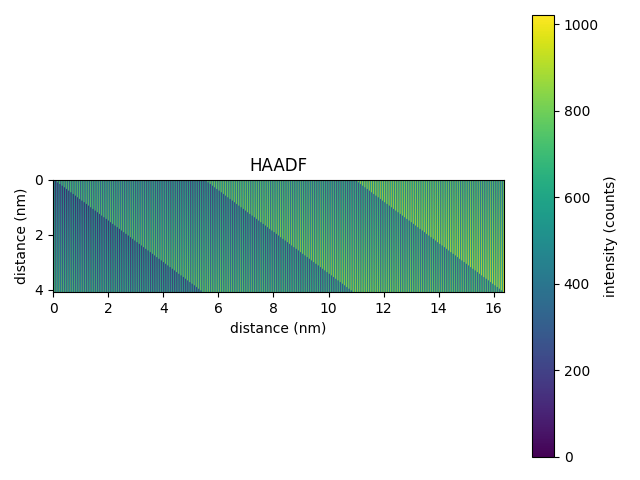

In [64]:
view = datasets[0].plot()